# 🏦 Bank Customer Churn Prediction using Machine Learning

### Classification Analysis of Bank Customer Data

## 📌 Introduction

Customer churn is an important problem in the banking industry. 
Customers may stop using banking services or close their accounts and move to another bank.

In this project, customer demographic, financial, and banking-related information is analyzed to predict whether a customer will leave the bank or continue using the bank's services.

Machine Learning classification algorithms are used to identify patterns in customer data and predict customer churn.

## 🤖 What is Classification?

Classification is a supervised Machine Learning technique used to predict a category or class based on input features.

In this project, the target variable is `churn`.

- `0` → Customer stayed with the bank
- `1` → Customer left the bank

Since the target variable contains two classes, this project is a **Binary Classification** problem.

## 🎯 Project Objective

The main objective of this project is to develop a Machine Learning classification model that predicts whether a bank customer will churn based on their demographic, financial, and banking-related information.

### Objectives

- Understand the bank customer dataset
- Perform data cleaning and preprocessing
- Analyze customer characteristics
- Explore the relationship between customer features and churn
- Visualize important patterns in the dataset
- Prepare the data for Machine Learning
- Build different classification models
- Evaluate model performance
- Compare the classification models
- Save the trained model
- Develop a Streamlit prediction application
- Deploy the application using Streamlit Cloud

## 🔄 Project Workflow

The project follows these major steps:

1. Import Required Libraries
2. Load the Dataset
3. Understand the Dataset
4. Check Data Types and Missing Values
5. Check Duplicate Records
6. Perform Exploratory Data Analysis
7. Analyze the Target Variable
8. Encode Categorical Variables
9. Prepare Features and Target
10. Split the Dataset into Training and Testing Data
11. Scale the Features
12. Train Classification Models
13. Evaluate Model Performance
14. Compare the Models
15. Save the Selected Model
16. Build the Streamlit Application
17. Deploy the Application using Streamlit Cloud

## 📂 Dataset Description

The dataset used for this project is:

**Bank Customer Churn Prediction.csv**

The dataset contains information about bank customers such as credit score, country, gender, age, tenure, account balance, number of products, credit card status, active membership, estimated salary, and churn status.

The dataset contains **10,000 customer records and 12 columns**.



## 📊 Dataset Columns

| Column | Description |
|---|---|
| `customer_id` | Unique identification number of the customer |
| `credit_score` | Credit score of the customer |
| `country` | Country of the customer |
| `gender` | Gender of the customer |
| `age` | Age of the customer |
| `tenure` | Number of years the customer has been with the bank |
| `balance` | Customer's bank account balance |
| `products_number` | Number of banking products used by the customer |
| `credit_card` | Indicates whether the customer has a credit card |
| `active_member` | Indicates whether the customer is an active bank member |
| `estimated_salary` | Estimated salary of the customer |
| `churn` | Target variable indicating whether the customer left the bank |

## 🎯 Target Variable

The target variable in this project is `churn`.

- `0` → Customer did not leave the bank
- `1` → Customer left the bank

Therefore, the target variable contains two possible classes:

**0 = Stayed**

**1 = Churned**

This makes the project a **Binary Classification** problem.

## 📚 Importing Required Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, Machine Learning model development, and model evaluation.

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### 🔎 Observation

The required libraries for data manipulation, data visualization, data preprocessing, classification model development, and model evaluation have been imported successfully.

## 📥 Loading the Dataset

The Bank Customer Churn Prediction dataset is loaded into a Pandas DataFrame for further analysis.

In [10]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 🔎 Observation

The dataset has been successfully loaded into a Pandas DataFrame.

The first five records are displayed to understand the structure and values of the dataset.

## 📐 Checking Dataset Shape

The shape of the dataset is checked to identify the total number of rows and columns.

In [11]:
df.shape

(10000, 12)

### 🔎 Observation

The dataset contains **10,000 rows and 12 columns**.

Each row represents a bank customer, while each column represents a customer attribute or the target variable.

## 📋 Displaying Column Names

The column names are displayed to understand the different features available in the dataset.

In [12]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

### 🔎 Observation

The dataset contains customer demographic, financial, and banking-related features along with the target variable `churn`.

The `churn` column will be used as the target variable for the classification models.

## 🔍 Dataset Information

The `info()` function is used to understand the structure of the dataset, including data types and non-null values.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


### 🔎 Observation

The dataset information shows the number of records, column names, data types, and non-null values.

This helps identify numerical and categorical features and also helps us check whether missing values are present.

## 📊 Statistical Summary

Descriptive statistics are generated for the numerical columns to understand their distribution and range.

In [14]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 🔎 Observation

The descriptive statistics provide information such as count, mean, standard deviation, minimum, maximum, and quartile values for the numerical features.

This helps us understand the general distribution and range of the numerical variables.

## ❌ Checking Missing Values

Missing values are checked in every column before performing further data analysis and Machine Learning preprocessing.

In [15]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

### 🔎 Observation

The number of missing values in each column is displayed.

If missing values are present, they need to be handled before training the Machine Learning models.


## 🧹 Checking Duplicate Records

Duplicate records are checked to identify whether the dataset contains any repeated customer records.

In [16]:
df.duplicated().sum()

np.int64(0)

### 🔎 Observation

The number of duplicate records in the dataset is displayed.

If duplicate records are present, they may need to be removed before further analysis and model training.


## 🎯 Churn Distribution

The distribution of the target variable `churn` is analyzed to understand the number of customers who stayed with the bank and the number of customers who left the bank.

In [17]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

### 🔎 Observation

The `churn` column shows the number of customers who stayed with the bank and the number of customers who left the bank.

- `0` represents customers who stayed.
- `1` represents customers who left.

This helps us understand the distribution of the target variable.

## 📊 Churn Percentage

The percentage of customers who stayed with the bank and the percentage of customers who left the bank are calculated.

In [18]:
churn_percentage = df['churn'].value_counts(normalize=True) * 100

churn_percentage.round(2)

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

### 🔎 Observation

The percentage distribution of customers based on the `churn` variable is displayed.

This helps us understand the proportion of customers who stayed with the bank and those who left the bank.

## 📊 Churn Distribution Visualization

A count plot is used to visualize the number of customers who stayed with the bank and the number of customers who left.

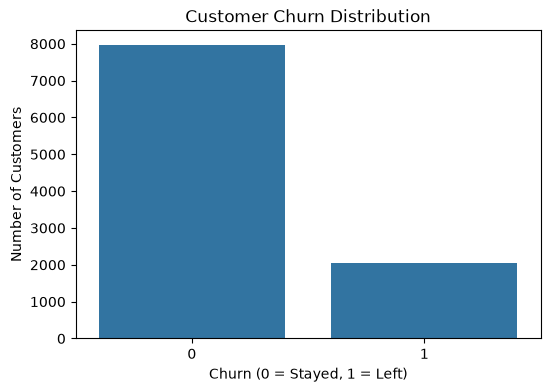

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(x='churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')

plt.show()

### 🔎 Observation

The count plot shows the distribution of customers based on their churn status.

Customers with `churn = 0` represent customers who stayed with the bank, while `churn = 1` represents customers who left the bank.

The graph helps us understand whether the target classes are balanced or imbalanced.

## 🔧 Separating Features and Target

The dataset is divided into input features (`X`) and the target variable (`y`).

The `churn` column is the target variable, while the remaining relevant columns are used as input features.

In [20]:
X = df.drop(columns=['churn', 'customer_id'])
y = df['churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 10)
Target shape: (10000,)


### 🔎 Observation

The target variable `churn` is separated from the input features.

The `customer_id` column is also removed because it is only an identifier and does not provide useful information for predicting customer churn.

## 🔧 Encoding Categorical Features

Machine Learning models require numerical input values. Therefore, the categorical columns `country` and `gender` are converted into numerical values using Label Encoding.

In [21]:
label_encoder = LabelEncoder()

X['country'] = label_encoder.fit_transform(X['country'])
X['gender'] = label_encoder.fit_transform(X['gender'])

X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


### 🔎 Observation

The categorical columns `country` and `gender` have been successfully converted into numerical values.

The dataset is now in a suitable format for further Machine Learning preprocessing and model training.

## 🔧 Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to train the Machine Learning models, while the testing data is used to evaluate their performance on unseen data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8000, 10)
Testing data shape: (2000, 10)


### 🔎 Observation

The dataset has been divided into training and testing sets.

80% of the data is used for training the models and 20% is used for testing.

The `stratify=y` parameter maintains a similar churn class distribution in both training and testing datasets.

## 🔧 Feature Scaling

Feature scaling is performed to bring the numerical features into a similar range.

StandardScaler is used to standardize the features by removing the mean and scaling them according to their standard deviation.

In [ ]:
om skleafrrn.model_selection import train_test_split

In [24]:
X = df.drop(columns=['churn', 'customer_id'])
y = df['churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 10)
Target shape: (10000,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8000, 10)
Testing data shape: (2000, 10)


## 🤖 Logistic Regression

In [28]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['churn', 'customer_id'])
y = df['churn']

# Encode categorical columns
country_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

X['country'] = country_encoder.fit_transform(X['country'])
X['gender'] = gender_encoder.fit_transform(X['gender'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8000, 10)
Testing data shape: (2000, 10)


In [29]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

lr_pred = logistic_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.5 %


### 🔎 Observation

The Logistic Regression model achieved an accuracy of 80.5% on the testing data.

In [30]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Support Vector Machine Accuracy:", round(svm_accuracy * 100, 2), "%")

Support Vector Machine Accuracy: 85.6 %


### 🔎 Observation

The Support Vector Machine model achieved an accuracy of 85.6% on the testing data.

## 🌳 Decision Tree Classifier

In [31]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 77.65 %


### 🔎 Observation

The Decision Tree model achieved an accuracy of 77.65% on the testing data.

## 🌲 Random Forest Classifier

In [33]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 86.4 %


### 🔎 Observation

The Random Forest model achieved an accuracy of 86.4% on the testing data.

## 📊 Model Accuracy Comparison

In [34]:
models = ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest']
accuracies = [lr_accuracy, svm_accuracy, dt_accuracy, rf_accuracy]

for model, accuracy in zip(models, accuracies):
    print(model, ":", round(accuracy * 100, 2), "%")


Logistic Regression : 80.5 %
SVM : 85.6 %
Decision Tree : 77.65 %
Random Forest : 86.4 %


### 🔎 Observation

The accuracy of all four classification models is compared to understand their performance on the testing data.

## 📊 Model Accuracy Comparison

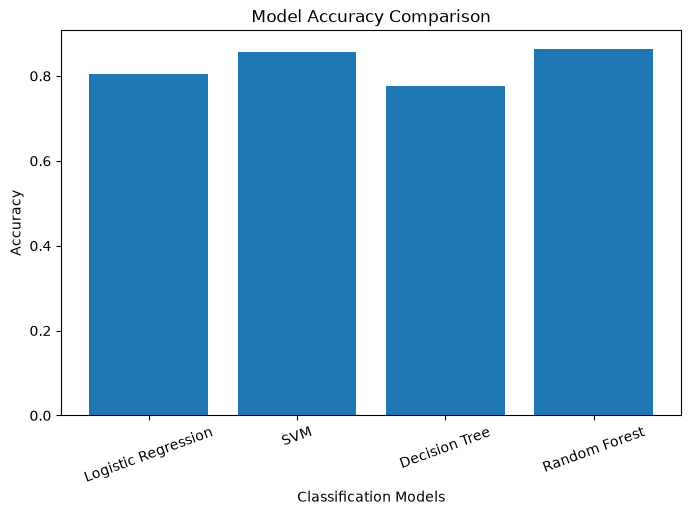

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Classification Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=20)
plt.show()

### 🔎 Observation

The bar graph shows the accuracy comparison of the four classification models on the testing data.

## 📋 Classification Report

The classification report is used to evaluate the performance of the Random Forest model using precision, recall, and F1-score.


In [36]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



### 🔎 Observation

The classification report displays the precision, recall, and F1-score of the Random Forest model for each churn class.

## 📊 Confusion Matrix

A confusion matrix is used to understand the correct and incorrect predictions made by the Random Forest model.

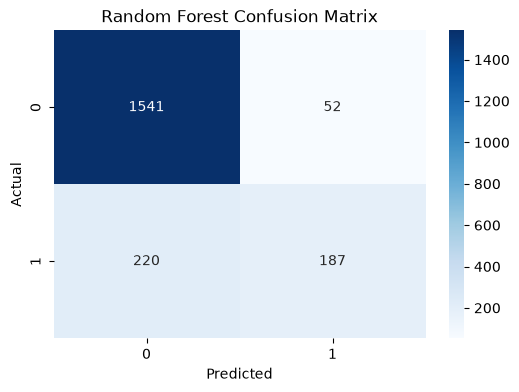

In [37]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


### 🔎 Observation

The confusion matrix shows the number of correct and incorrect predictions made by the Random Forest model for both churn classes.

## 💾 Saving the Random Forest Model

The Random Forest model is saved so that the trained model can be reused later without training it again.

In [38]:
import pickle

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


### 🔎 Observation

The trained Random Forest model has been successfully saved as a `.pkl` file.

The saved model can be loaded later for making predictions without retraining the model.

In [40]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

with open("country_encoder.pkl", "wb") as file:
    pickle.dump(country_encoder, file)

with open("gender_encoder.pkl", "wb") as file:
    pickle.dump(gender_encoder, file)

print("Preprocessing files saved successfully.")

Preprocessing files saved successfully.


## 🚀 Streamlit Application

The trained Random Forest model can be integrated into a Streamlit application to provide an interactive customer churn prediction interface.

The application allows users to enter customer details and receive a churn prediction.

### 🔎 Observation

The Machine Learning model is ready to be integrated with a Streamlit application for customer churn prediction.